## Example 3a:
Exploratory study of how the uncertainty in the predicted aberrations depends on how far the beam is from focus.

We now take a break from ML to do some physics.

A mixed-density model is fitted on single-z images, similarly to in [`zstack_decoding/example_2d.ipynb`](zstack_decoding/example_2d.ipynb).
The model is then used to simulate a batch of z-stacks and their true, underlying aberrations. Single-z images from those z-stacks are
then run through inference, and the predicted uncertainty for each coefficient is plotted as a function of defocus through each z-stack.

The results show the phase coefficients responsible for beam translation (predominantly $Z_{1}^{\pm1}$) becoming most clearly defined
at the focal plane, where the beam is tightest. Meanwhile, other phase coefficients become maximally uncertain at the focal plane,
with their uncertainty tapering down as the defocus grows. These results are consistent with Fourier theory.

In [1]:
import itertools
import logging
import math
import warnings

import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config import NoiseConfig, OpticalConfig, PriorConfig, SimulationConfig, TrainingConfig, ZernikeConfig
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.zstack_decoding import (
    ZstackSolver_MixedDensity,
    make_object_distribution,
)

#### Simulation setup

In [4]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.15  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.9
medium_index = 1.54
immersion_index = 1.0
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 6  # max Zernike N
max_amplitude_order = 4  # max Zernike N
z_jitter = 1.5  # um

device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_cfg = TrainingConfig(
    learning_rate=1e-3,
    weight_decay=1e-3,
    batch_size=32,
    generator_chunk=4,
    steps_per_epoch=200,
    val_batches=32,
    val_seed=42,
    mixing_warmup_epochs=10,
)
sim_cfg = SimulationConfig(
    pupil_grid_size=pupil_grid_size,
    object_grid_size=object_grid_size,
    object_pixel_size=object_pixel_size,
    ftype=torch.float32,
    ctype=torch.complex64,
)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(
    max_phase_order,
    allowed_nm=(
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -3), (3, -1), (3, 1), (3, 3),
        (4, -4), (4, -2), (4, 0), (4, 2), (4, 4),
        (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5),
    )
)
amp_cfg = ZernikeConfig(
    max_amplitude_order,
    allowed_nm=(
        (0, 0), (2, 0), (4, 0)
    )
)
noise_cfg = NoiseConfig(
    min_photons=100_000,
    max_photons=1_000_000,
    max_background=1_000,
    read_noise=10,
)
# noise_cfg = None  # no noise, to better estimate the fundamental limit

In [6]:
object_distrib = make_object_distribution(sim_cfg.object_grid_size, sim_cfg.object_pixel_size, bead_diameter)
phase_prior = PriorConfig(0.05, 1)
amp_prior = PriorConfig(0.05, 2)

#### Fitting a model

In [7]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    num_components=2,
    noise_cfg=noise_cfg,
    hidden_channels=(8, 8),
    embedding_dims=32,
)
solver = solver.to(device)

Seed set to 123


In [8]:
trainer = pl.Trainer(
    max_epochs=200,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)

Sanity Checking: |                                               | 0/? [00:00<?, ?it/s]

Training: |                                                      | 0/? [00:00<?, ?it/s]

In [9]:
# torch.save(solver, "example_3_fitted.pt")  # uncomment to save fitted model as a checkpoint

#### Analysis (i.e., the good stuff)

In [10]:
# solver = torch.load("example_3_fitted.pt", weights_only=False)  # uncomment to load a previously fitted and saved model

In [11]:
batch_size = 16
z_max = 1.5
num_z = 11

In [12]:
z = torch.linspace(-z_max, z_max, num_z).to(solver.device)
phase_coefs, amp_coefs = solver.generate_phase_amp_coefficients(batch_size, solver.device)

In [13]:
z_exp = z.unsqueeze(0).expand((batch_size, num_z)).reshape(batch_size*num_z)
phase_coefs_exp = phase_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)
amp_coefs_exp = amp_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)

images = solver.simulate_stacks(z_exp, phase_coefs_exp, amp_coefs_exp)
images = solver.apply_noise(images)
images = solver.normalize_stack(images)
mixture_family = solver.predict_distribution(images)
mixture = mixture_family.mixture_distribution
dist = mixture_family.component_distribution

covariances = dist.covariance_matrix
sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
sigmas = sigmas.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, num_components, num_coefficients]

images = images.squeeze(1).unflatten(0, (batch_size, num_z))  # [B, Z, H, W]

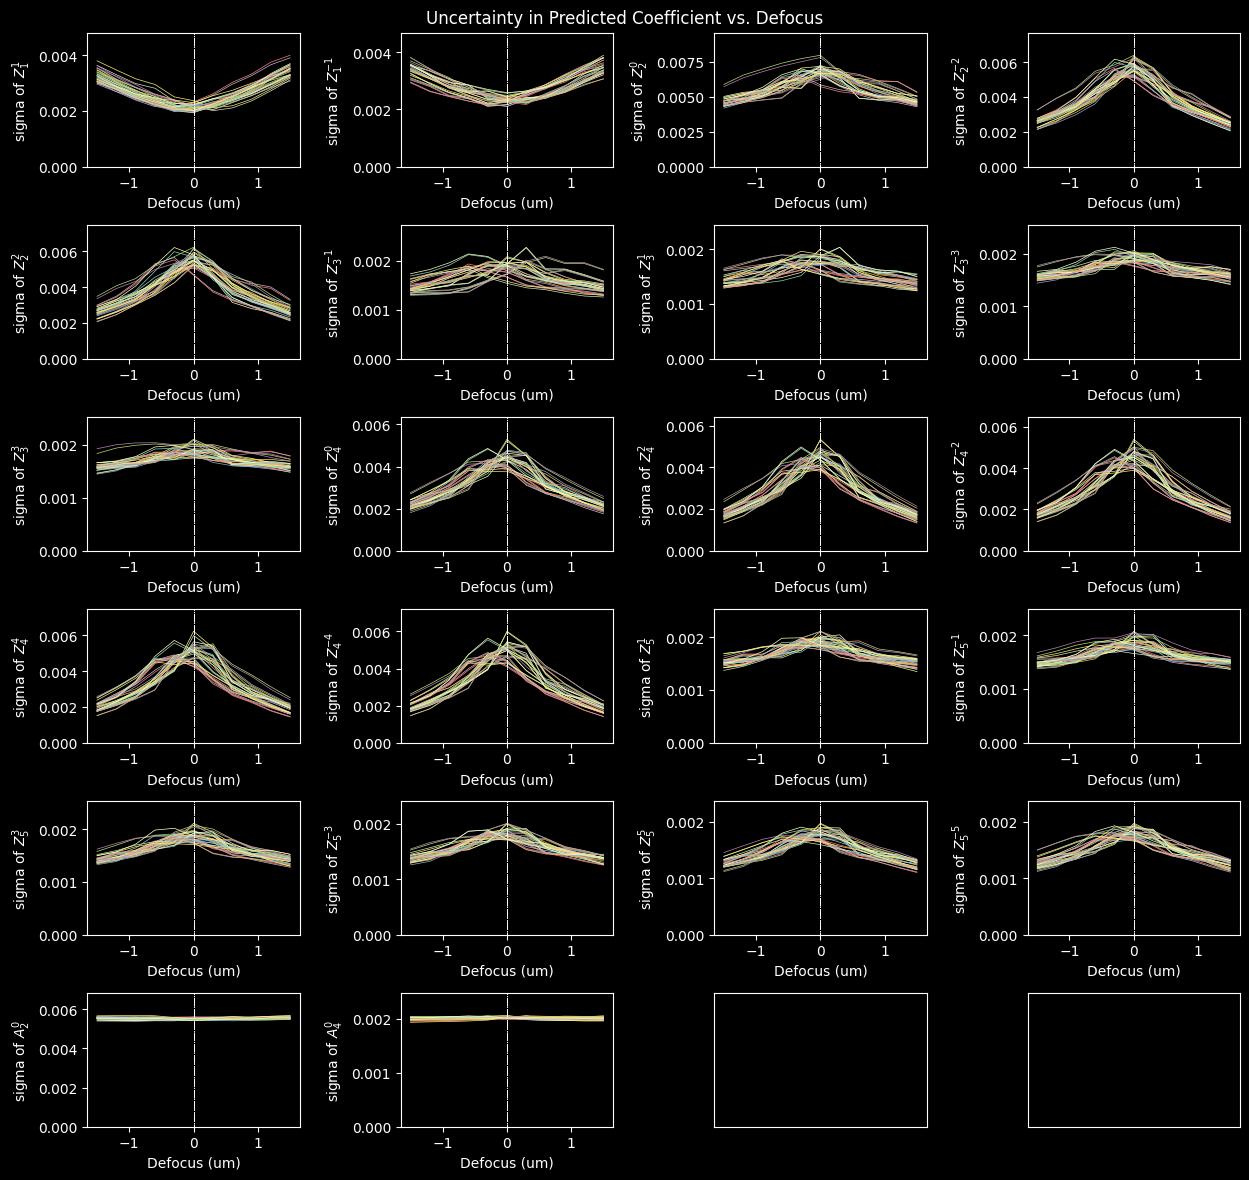

In [14]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_coefs = solver.num_nonpiston_coefs
num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)

labels = solver.nonpiston_labels

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_coefs:
        for bidx, cidx in itertools.product(range(batch_size), range(solver.num_components)):
            ax.plot(z.numpy(force=True), sigmas[bidx, :, cidx, i].numpy(force=True), lw=0.5)
            ax.set_ylabel(f"sigma of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
            ax.axvline(0, ls=":", lw=0.5)
        max_val = sigmas[:, :, :, i].amax().numpy(force=True)
        ax.set_ylim(0, max_val * 1.2)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.suptitle("Uncertainty in Predicted Coefficient vs. Defocus")
fig.tight_layout()

For almost all coefficients, predictions become more uncertain near the focal plane, where aberrations become both less pronounced and less distinct.

Major exceptions include $Z_{1}^{\pm1}$, which control translation and become better-conditioned the more focused the spot is.
The amplitude coefficients modeled show no strong dependencies to begin with.

These results are unsurprising based on wave physics. Phase variations in the pupil (Fourier) plane are conjugate to momentum in the image/object planes, which
Heisenberg tells us becomes maximally uncertain when the beam's position is well-defined.
By the same token, in the far field (large defocus limit), the intensity
distribution mirrors the angular spectrum, allowing angular frequency (and therefore, momentum) to be optimally resolved.

Put less formally, but perhaps more obviously: you can't see changes in the beam shape when it's all just one round spot.